In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

sys.path.append("..")

from src.data.labels import load_scp_statements, DIAGNOSTIC_CLASSES
from src.data.splitting import create_patient_wise_split, check_patient_overlap, summarize_split
from src.data.preprocessing import Compose, EnsureFloat32, RemoveNaN, PadOrCrop, PerLeadZScore
from src.data.dataset import PTBXLDataset

from src.models.dependency_gated_sequence import DependencyGatedSequenceClassifier
from src.training.trainer import Trainer
from src.evaluation.classification_metrics import (
    logits_to_probabilities,
    compute_multilabel_metrics,
    compute_per_class_metrics,
)

In [2]:
DATASET_PATH = Path("../dataset/ptbxl")

SAMPLING_RATE = 100
TARGET_LENGTH = 1000
BATCH_SIZE = 16
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42

CHECKPOINT_DIR = Path("../outputs/checkpoints")
CHECKPOINT_NAME = "dependency_gated_sequence_best.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5070


In [3]:
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

In [4]:
metadata = pd.read_csv(DATASET_PATH / "ptbxl_database.csv")
scp_statements = load_scp_statements(DATASET_PATH)

print(metadata.shape)
metadata.head()

(21799, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [5]:
train_metadata, val_metadata, test_metadata = create_patient_wise_split(
    metadata=metadata,
    patient_col="patient_id",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=RANDOM_STATE,
)

print("No patient overlap:", check_patient_overlap(train_metadata, val_metadata, test_metadata))
summarize_split(train_metadata, val_metadata, test_metadata)

No patient overlap: True


,split,num_records,num_patients
0,train,15270,13208
1,validation,3251,2830
2,test,3278,2831


In [6]:
transform = Compose([
    EnsureFloat32(),
    RemoveNaN(),
    PadOrCrop(target_length=TARGET_LENGTH),
    PerLeadZScore(),
])

In [7]:
train_dataset = PTBXLDataset(
    metadata=train_metadata,
    dataset_path=DATASET_PATH,
    scp_statements=scp_statements,
    sampling_rate=SAMPLING_RATE,
    transform=transform,
)

val_dataset = PTBXLDataset(
    metadata=val_metadata,
    dataset_path=DATASET_PATH,
    scp_statements=scp_statements,
    sampling_rate=SAMPLING_RATE,
    transform=transform,
)

test_dataset = PTBXLDataset(
    metadata=test_metadata,
    dataset_path=DATASET_PATH,
    scp_statements=scp_statements,
    sampling_rate=SAMPLING_RATE,
    transform=transform,
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

15270 3251 3278


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

In [9]:
batch = next(iter(train_loader))

print(batch["signal"].shape)
print(batch["label"].shape)
print(batch["label"][0])
print("Class order:", DIAGNOSTIC_CLASSES)

torch.Size([16, 12, 1000])
torch.Size([16, 5])
tensor([0., 0., 0., 1., 0.])
Class order: ['NORM', 'MI', 'STTC', 'CD', 'HYP']


In [10]:
model = DependencyGatedSequenceClassifier(
    input_size=12,
    d_model=128,
    num_layers=4,
    num_classes=len(DIAGNOSTIC_CLASSES),
    expansion=2,
    kernel_size=7,
    dropout=0.3,
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

In [11]:
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    save_dir=CHECKPOINT_DIR,
    scheduler=scheduler,
)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    checkpoint_name=CHECKPOINT_NAME,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
)

Epoch [001/050] Train Loss: 0.4032 | Val Loss: 0.3549
Saved best model to: ../outputs/checkpoints/dependency_gated_sequence_best.pt
Epoch [002/050] Train Loss: 0.3279 | Val Loss: 0.3356
Saved best model to: ../outputs/checkpoints/dependency_gated_sequence_best.pt
Epoch [003/050] Train Loss: 0.3060 | Val Loss: 0.3082
Saved best model to: ../outputs/checkpoints/dependency_gated_sequence_best.pt
Epoch [004/050] Train Loss: 0.2924 | Val Loss: 0.3282
Epoch [005/050] Train Loss: 0.2846 | Val Loss: 0.2968
Saved best model to: ../outputs/checkpoints/dependency_gated_sequence_best.pt
Epoch [006/050] Train Loss: 0.2790 | Val Loss: 0.2886
Saved best model to: ../outputs/checkpoints/dependency_gated_sequence_best.pt
Epoch [007/050] Train Loss: 0.2721 | Val Loss: 0.2875
Saved best model to: ../outputs/checkpoints/dependency_gated_sequence_best.pt
Epoch [008/050] Train Loss: 0.2676 | Val Loss: 0.2809
Saved best model to: ../outputs/checkpoints/dependency_gated_sequence_best.pt
Epoch [009/050] Train 

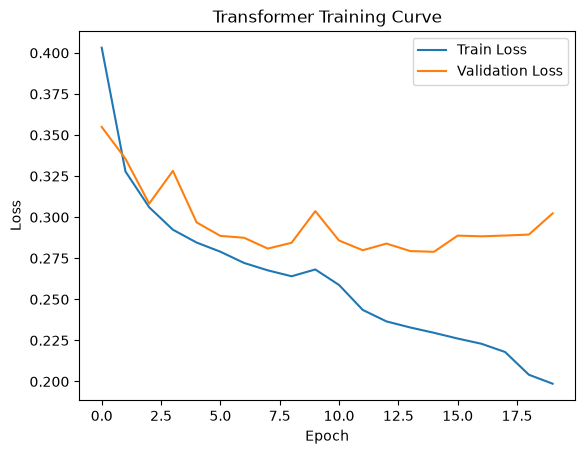

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training Curve")
plt.legend()
plt.show()

In [13]:
trainer.load_checkpoint(CHECKPOINT_NAME)
model = trainer.model
model.eval()

Loaded checkpoint from: ../outputs/checkpoints/dependency_gated_sequence_best.pt


DependencyGatedSequenceClassifier(
  (input_projection): Linear(in_features=12, out_features=128, bias=True)
  (sequence_blocks): Sequential(
    (0): MambaInspiredBlock(
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (input_projection): Linear(in_features=128, out_features=512, bias=True)
      (depthwise_conv): Conv1d(256, 256, kernel_size=(7,), stride=(1,), padding=(3,), groups=256)
      (activation): SiLU()
      (gate_projection): Linear(in_features=256, out_features=256, bias=True)
      (output_projection): Linear(in_features=256, out_features=128, bias=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (1): MambaInspiredBlock(
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (input_projection): Linear(in_features=128, out_features=512, bias=True)
      (depthwise_conv): Conv1d(256, 256, kernel_size=(7,), stride=(1,), padding=(3,), groups=256)
      (activation): SiLU()
      (gate_projection): Linear(in_features=2

In [14]:
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        signals = batch["signal"].to(DEVICE)
        labels = batch["label"].cpu().numpy()

        logits = model(signals)
        probs = logits_to_probabilities(logits)

        all_labels.append(labels)
        all_probs.append(probs)

y_true = np.vstack(all_labels)
y_prob = np.vstack(all_probs)

print(y_true.shape)
print(y_prob.shape)

(3278, 5)
(3278, 5)


In [15]:
test_metrics = compute_multilabel_metrics(
    y_true=y_true,
    y_prob=y_prob,
    threshold=0.5,
)

test_metrics

{'micro_f1': 0.7669059312429165,
 'macro_f1': 0.7211852872873845,
 'micro_precision': 0.8081210191082803,
 'macro_precision': 0.781367748498831,
 'micro_recall': 0.7296908698777858,
 'macro_recall': 0.6829204939176822,
 'hamming_loss': 0.11293471629042098,
 'macro_auroc': 0.9253567216209682,
 'macro_auprc': 0.8086052785662275}

In [16]:
per_class_metrics = compute_per_class_metrics(
    y_true=y_true,
    y_prob=y_prob,
    class_names=DIAGNOSTIC_CLASSES,
    threshold=0.5,
)

pd.DataFrame(per_class_metrics).T

,f1,precision,recall,auroc,auprc
NORM,0.841415,0.888376,0.799169,0.953190,0.933578
MI,0.750161,0.778667,0.723668,0.932661,0.857207
STTC,0.745912,0.729397,0.763192,0.930216,0.807032
CD,0.788047,0.817003,0.761074,0.941117,0.874659
HYP,0.480392,0.693396,0.367500,0.869600,0.570550


In [17]:
RESULTS_DIR = Path("../outputs/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame([test_metrics]).to_csv(
    RESULTS_DIR / "dependency_gated_sequence_overall_metrics.csv",
    index=False,
)

pd.DataFrame(per_class_metrics).T.to_csv(
    RESULTS_DIR / "dependency_gated_sequence_per_class_metrics.csv",
)